# 03 — Exploratory Data Analysis
Key findings that shaped feature engineering and model design.

**Key results:** 21.2% delay rate · Late aircraft = 39.9% of delay minutes · Departure hour is strongest time feature

**Input:** `dataset/data.parquet` — 20.6M cleaned flights

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_parquet("dataset/data.parquet")

In [3]:
data.head()

,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,...,ACTUAL_ELAPSED_TIME,AIR_TIME,FLIGHTS,DISTANCE,DISTANCE_GROUP,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,2023,1,1,1,7,2023-01-01,9E,20363,N131EV,5244.0,...,134.0,91.0,1.0,740.0,3,NaN,NaN,NaN,NaN,NaN
1,2023,1,1,1,7,2023-01-01,9E,20363,N131EV,5317.0,...,159.0,126.0,1.0,740.0,3,NaN,NaN,NaN,NaN,NaN
2,2023,1,1,1,7,2023-01-01,9E,20363,N131EV,5397.0,...,93.0,60.0,1.0,382.0,2,NaN,NaN,NaN,NaN,NaN
3,2023,1,1,1,7,2023-01-01,9E,20363,N133EV,5076.0,...,109.0,88.0,1.0,563.0,3,NaN,NaN,NaN,NaN,NaN
4,2023,1,1,1,7,2023-01-01,9E,20363,N133EV,5076.0,...,96.0,75.0,1.0,563.0,3,NaN,NaN,NaN,NaN,NaN


## Delay Rate by Airline

In [4]:
delay_by_airline = (data.groupby('OP_UNIQUE_CARRIER')
                    .agg(total_flights=('ARR_DEL15', 'count'),
                         delayed=('ARR_DEL15', 'sum'),
                         avg_delay_min=('ARR_DELAY', 'mean'))
                    .assign(delay_rate=lambda x: x['delayed'] / x['total_flights'] * 100)
                    .sort_values('delay_rate', ascending=False))

print(delay_by_airline.to_string())

                   total_flights   delayed  avg_delay_min  delay_rate
OP_UNIQUE_CARRIER                                                    
F9                        571133  167208.0      16.001212   29.276543
B6                        730301  202959.0      13.641449   27.791144
NK                        705662  177522.0      10.213748   25.156803
AA                       2847015  711324.0      13.788335   24.984905
G4                        359199   86978.0      12.314853   24.214433
OH                        651427  145602.0      10.687294   22.351238
AS                        724893  156579.0       3.949166   21.600291
WN                       4202672  893952.0       5.657402   21.271039
UA                       2252227  465313.0       6.476603   20.660129
MQ                        791847  159625.0       5.571200   20.158566
HA                        236810   44666.0       6.956256   18.861535
OO                       2223949  418520.0       7.158489   18.818777
DL                  

In [5]:
data.OP_UNIQUE_CARRIER.value_counts()

OP_UNIQUE_CARRIER
WN    4202672
DL    2983204
AA    2847015
UA    2252227
OO    2223949
YX     915838
MQ     791847
B6     730301
AS     724893
NK     705662
OH     651427
F9     571133
9E     391977
G4     359199
HA     236810
Name: count, dtype: int64

In [6]:
data.OP_UNIQUE_CARRIER.unique()

array(['9E', 'AA', 'AS', 'B6', 'DL', 'F9', 'G4', 'HA', 'MQ', 'NK', 'OH',
       'OO', 'UA', 'WN', 'YX'], dtype=object)

In [7]:
airline_names = {
    'AA': 'American Airlines',
    'DL': 'Delta',
    'UA': 'United',
    'WN': 'Southwest',
    'B6': 'JetBlue',
    'AS': 'Alaska Airlines',
    'NK': 'Spirit',
    'F9': 'Frontier',
    'G4': 'Allegiant',
    'HA': 'Hawaiian',
    'MQ': 'Envoy Air',
    'OO': 'SkyWest',
    'YX': 'Republic Airways',
    'OH': 'PSA Airlines',
    '9E': 'Endeavor Air',
}

data['AIRLINE_NAME'] = data['OP_UNIQUE_CARRIER'].map(airline_names)
print(data['AIRLINE_NAME'].value_counts().to_string())

AIRLINE_NAME
Southwest            4202672
Delta                2983204
American Airlines    2847015
United               2252227
SkyWest              2223949
Republic Airways      915838
Envoy Air             791847
JetBlue               730301
Alaska Airlines       724893
Spirit                705662
PSA Airlines          651427
Frontier              571133
Endeavor Air          391977
Allegiant             359199
Hawaiian              236810


In [8]:
delay_by_airline = (data.groupby('AIRLINE_NAME')
                    .agg(total_flights=('ARR_DEL15', 'count'),
                         delayed=('ARR_DEL15', 'sum'),
                         avg_delay_min=('ARR_DELAY', 'mean'))
                    .assign(delay_rate=lambda x: x['delayed'] / x['total_flights'] * 100)
                    .sort_values('delay_rate', ascending=False))

print(delay_by_airline.round(2).to_string())

                   total_flights   delayed  avg_delay_min  delay_rate
AIRLINE_NAME                                                         
Frontier                  571133  167208.0          16.00       29.28
JetBlue                   730301  202959.0          13.64       27.79
Spirit                    705662  177522.0          10.21       25.16
American Airlines        2847015  711324.0          13.79       24.98
Allegiant                 359199   86978.0          12.31       24.21
PSA Airlines              651427  145602.0          10.69       22.35
Alaska Airlines           724893  156579.0           3.95       21.60
Southwest                4202672  893952.0           5.66       21.27
United                   2252227  465313.0           6.48       20.66
Envoy Air                 791847  159625.0           5.57       20.16
Hawaiian                  236810   44666.0           6.96       18.86
SkyWest                  2223949  418520.0           7.16       18.82
Delta               

In [9]:
data.ARR_DELAY.value_counts()

ARR_DELAY
-11.0      568363
-12.0      567558
-10.0      564282
-13.0      559714
-9.0       553244
            ...  
 2294.0         1
 2899.0         1
 2574.0         1
-95.0           1
 3282.0         1
Name: count, Length: 2268, dtype: int64

## Delay Distribution

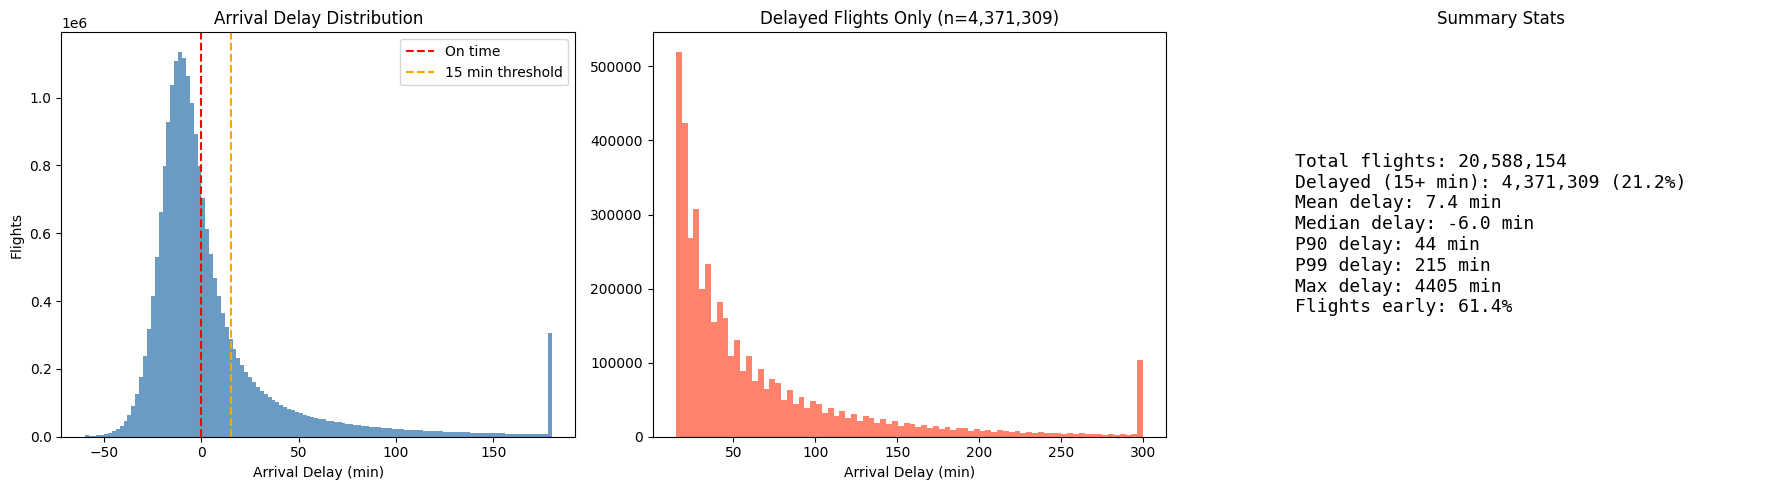


Delay percentiles:
  P50: -6 min
  P75: 10 min
  P90: 44 min
  P95: 84 min
  P99: 215 min


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(data['ARR_DELAY'].clip(-60, 180), bins=120, color='steelblue',
             edgecolor='none', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='On time')
axes[0].axvline(15, color='orange', linestyle='--', linewidth=1.5, label='15 min threshold')
axes[0].set_xlabel('Arrival Delay (min)')
axes[0].set_ylabel('Flights')
axes[0].set_title('Arrival Delay Distribution')
axes[0].legend()

delayed = data[data['ARR_DEL15'] == 1]['ARR_DELAY']
axes[1].hist(delayed.clip(15, 300), bins=80, color='tomato', edgecolor='none', alpha=0.8)
axes[1].set_xlabel('Arrival Delay (min)')
axes[1].set_title(f'Delayed Flights Only (n={len(delayed):,})')

stats = {
    'Total flights': f"{len(data):,}",
    'Delayed (15+ min)': f"{len(delayed):,} ({data['ARR_DEL15'].mean()*100:.1f}%)",
    'Mean delay': f"{data['ARR_DELAY'].mean():.1f} min",
    'Median delay': f"{data['ARR_DELAY'].median():.1f} min",
    'P90 delay': f"{data['ARR_DELAY'].quantile(0.90):.0f} min",
    'P99 delay': f"{data['ARR_DELAY'].quantile(0.99):.0f} min",
    'Max delay': f"{data['ARR_DELAY'].max():.0f} min",
    'Flights early': f"{(data['ARR_DELAY'] < 0).mean()*100:.1f}%",
}
axes[2].axis('off')
table_text = '\n'.join([f"{k}: {v}" for k, v in stats.items()])
axes[2].text(0.1, 0.5, table_text, fontsize=13, family='monospace',
             verticalalignment='center', transform=axes[2].transAxes)
axes[2].set_title('Summary Stats')

plt.tight_layout()
plt.savefig('eda_plots/01_delay_distribution.png', bbox_inches='tight')
plt.show()

print("\nDelay percentiles:")
for p in [50, 75, 90, 95, 99]:
    print(f"  P{p}: {data['ARR_DELAY'].quantile(p/100):.0f} min")

## Overall Delay Statistics

In [22]:
data['FL_DATE'] = pd.to_datetime(data['FL_DATE'])

print(f"Total flights: {len(data):,}")
print(f"Delayed flights (15+ min late): {data['ARR_DEL15'].sum():,.0f}")
print(f"Delay rate: {data['ARR_DEL15'].mean()*100:.1f}%")
print(f"Mean arrival delay: {data['ARR_DELAY'].mean():.1f} min")
print(f"Median arrival delay: {data['ARR_DELAY'].median():.1f} min")

Total flights: 20,588,154
Delayed flights (15+ min late): 4,371,309
Delay rate: 21.2%
Mean arrival delay: 7.4 min
Median arrival delay: -6.0 min


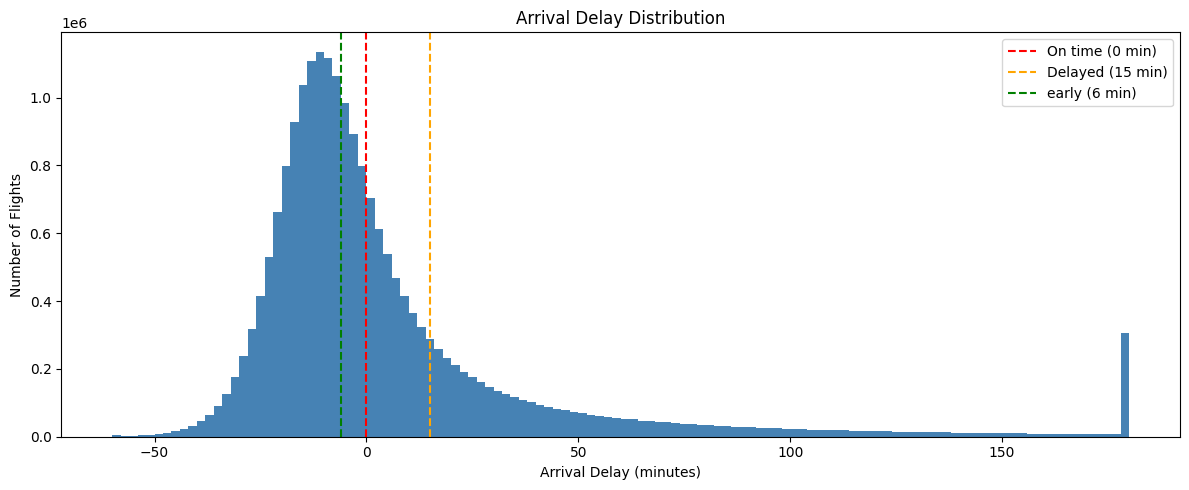

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(data['ARR_DELAY'].clip(-60, 180), bins=120, color='steelblue', edgecolor='none')
ax.axvline(0, color='red', linestyle='--', label='On time (0 min)')
ax.axvline(15, color='orange', linestyle='--', label='Delayed (15 min)')
ax.axvline(-6, color='green', linestyle='--', label='early (6 min)')
ax.set_xlabel('Arrival Delay (minutes)')
ax.set_ylabel('Number of Flights')
ax.set_title('Arrival Delay Distribution')
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
print("Delay percentiles:")
for p in [25, 50, 75, 90, 95, 99]:
    val = data['ARR_DELAY'].quantile(p/100)
    print(f"  P{p}: {val:.0f} min")

print(f"\nFlights arriving early: {(data['ARR_DELAY'] < 0).mean()*100:.1f}%")
print(f"Flights 0-15 min late: {((data['ARR_DELAY'] >= 0) & (data['ARR_DELAY'] < 15)).mean()*100:.1f}%")
print(f"Flights 15-60 min late: {((data['ARR_DELAY'] >= 15) & (data['ARR_DELAY'] < 60)).mean()*100:.1f}%")
print(f"Flights 60+ min late: {(data['ARR_DELAY'] >= 60).mean()*100:.1f}%")

Delay percentiles:
  P25: -15 min
  P50: -6 min
  P75: 10 min
  P90: 44 min
  P95: 84 min
  P99: 215 min

Flights arriving early: 61.4%
Flights 0-15 min late: 17.4%
Flights 15-60 min late: 13.8%
Flights 60+ min late: 7.5%


## Delay Rate by Hour of Day
Evening flights accumulate delays — motivates `DEP_HOUR` and `origin_hour_delay_rate_30d` features.

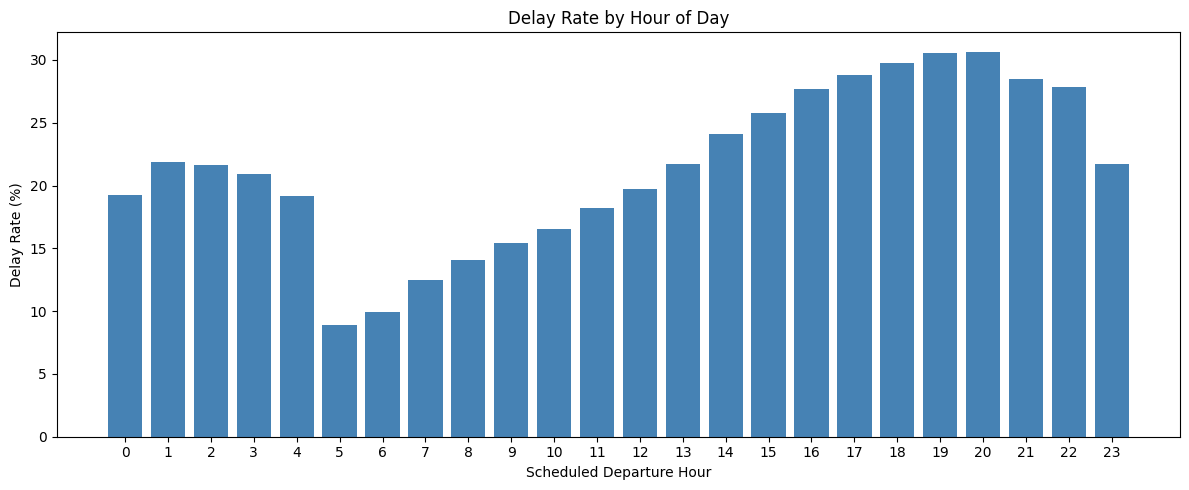

 DEP_HOUR  delay_rate
        0    0.192186
        1    0.218400
        2    0.216096
        3    0.209508
        4    0.191935
        5    0.088978
        6    0.098967
        7    0.125088
        8    0.140546
        9    0.154464
       10    0.165524
       11    0.182025
       12    0.197132
       13    0.217565
       14    0.240786
       15    0.258054
       16    0.276895
       17    0.288100
       18    0.297555
       19    0.305380
       20    0.306694
       21    0.285203
       22    0.278851
       23    0.216973


In [25]:
data['DEP_HOUR'] = (data['CRS_DEP_TIME'] // 100).clip(0, 23)

hourly = data.groupby('DEP_HOUR').agg(
    flights=('ARR_DEL15', 'count'),
    delay_rate=('ARR_DEL15', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly['DEP_HOUR'], hourly['delay_rate'] * 100, color='steelblue')
ax.set_xlabel('Scheduled Departure Hour')
ax.set_ylabel('Delay Rate (%)')
ax.set_title('Delay Rate by Hour of Day')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

print(hourly[['DEP_HOUR', 'delay_rate']].to_string(index=False))

## Delay Rate by Day of Week

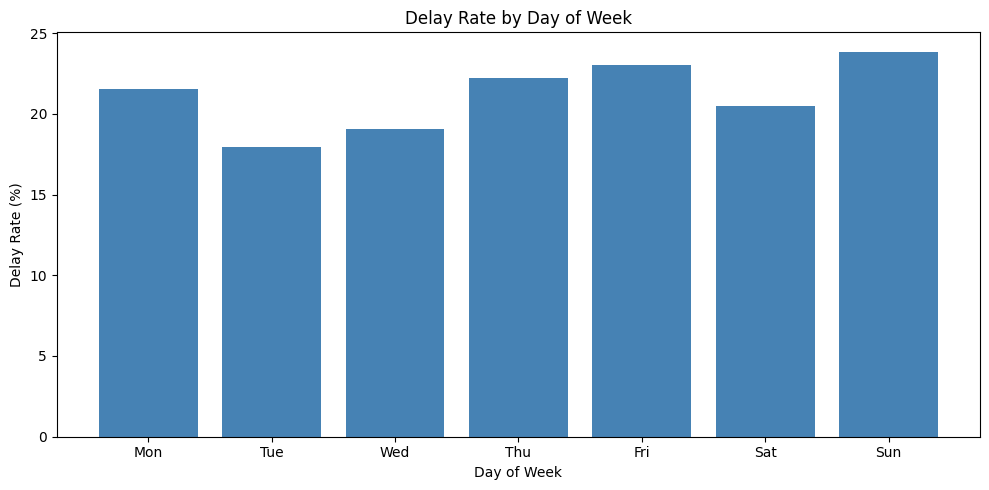

DAY_NAME  flights  delay_rate
     Mon  3084888    0.215656
     Tue  2830633    0.179363
     Wed  2861731    0.190672
     Thu  3044499    0.222381
     Fri  3065548    0.230281
     Sat  2659850    0.204639
     Sun  3041005    0.238535


In [26]:
day_names = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
data['DAY_NAME'] = data['DAY_OF_WEEK'].map(day_names)

daily = data.groupby('DAY_OF_WEEK').agg(
    flights=('ARR_DEL15', 'count'),
    delay_rate=('ARR_DEL15', 'mean')
).reset_index()
daily['DAY_NAME'] = daily['DAY_OF_WEEK'].map(day_names)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(daily['DAY_NAME'], daily['delay_rate'] * 100, color='steelblue')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Delay Rate (%)')
ax.set_title('Delay Rate by Day of Week')
plt.tight_layout()
plt.show()

print(daily[['DAY_NAME', 'flights', 'delay_rate']].to_string(index=False))

## Delay Rate by Month

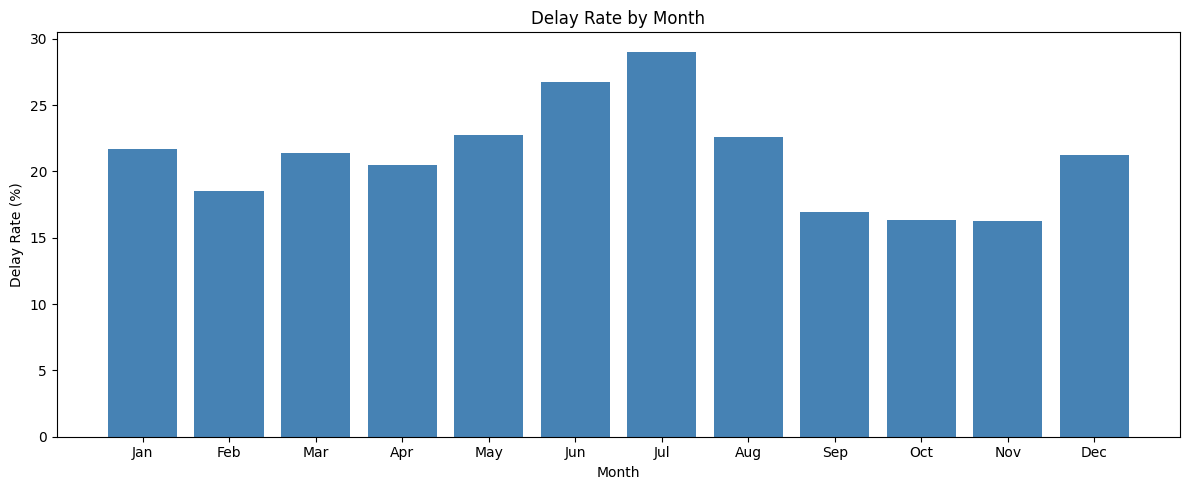

 MONTH  delay_rate
     1    0.216691
     2    0.184851
     3    0.213869
     4    0.204960
     5    0.227642
     6    0.267426
     7    0.290294
     8    0.225771
     9    0.169213
    10    0.163657
    11    0.162412
    12    0.212327


In [27]:
monthly = data.groupby('MONTH').agg(
    flights=('ARR_DEL15', 'count'),
    delay_rate=('ARR_DEL15', 'mean')
).reset_index()

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly['MONTH'], monthly['delay_rate'] * 100, color='steelblue')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_xlabel('Month')
ax.set_ylabel('Delay Rate (%)')
ax.set_title('Delay Rate by Month')
plt.tight_layout()
plt.show()

print(monthly[['MONTH', 'delay_rate']].to_string(index=False))

## Delay Cause Breakdown
Late aircraft cascade is the dominant cause (39.9% of delay minutes) — motivates cascade feature engineering in notebook 05.

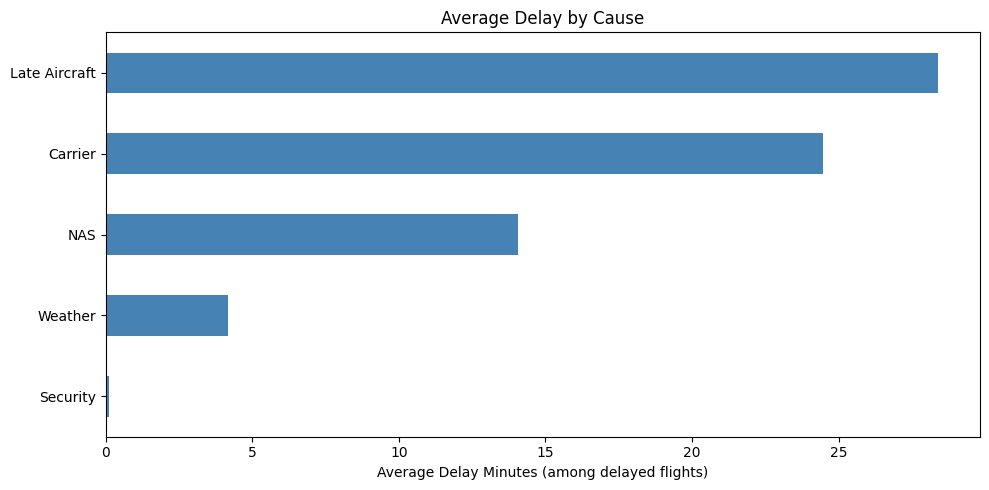

Average minutes per cause (delayed flights only):
Late Aircraft    28.4
Carrier          24.5
NAS              14.0
Weather           4.2
Security          0.1
dtype: float64

Share of total delay minutes:
Late Aircraft    39.9
Carrier          34.4
NAS              19.7
Weather           5.9
Security          0.2
dtype: float64


In [28]:
cause_cols = ['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 
              'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']

delayed = data[data['ARR_DEL15'] == 1]

cause_means = delayed[cause_cols].mean()
cause_means.index = ['Carrier', 'Weather', 'NAS', 'Security', 'Late Aircraft']

fig, ax = plt.subplots(figsize=(10, 5))
cause_means.sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Average Delay Minutes (among delayed flights)')
ax.set_title('Average Delay by Cause')
plt.tight_layout()
plt.show()

print("Average minutes per cause (delayed flights only):")
print(cause_means.sort_values(ascending=False).round(1))

cause_total = delayed[cause_cols].sum()
cause_total.index = ['Carrier', 'Weather', 'NAS', 'Security', 'Late Aircraft']
cause_pct = (cause_total / cause_total.sum() * 100).round(1)
print("\nShare of total delay minutes:")
print(cause_pct.sort_values(ascending=False))

## Worst and Best Airports by Delay Rate

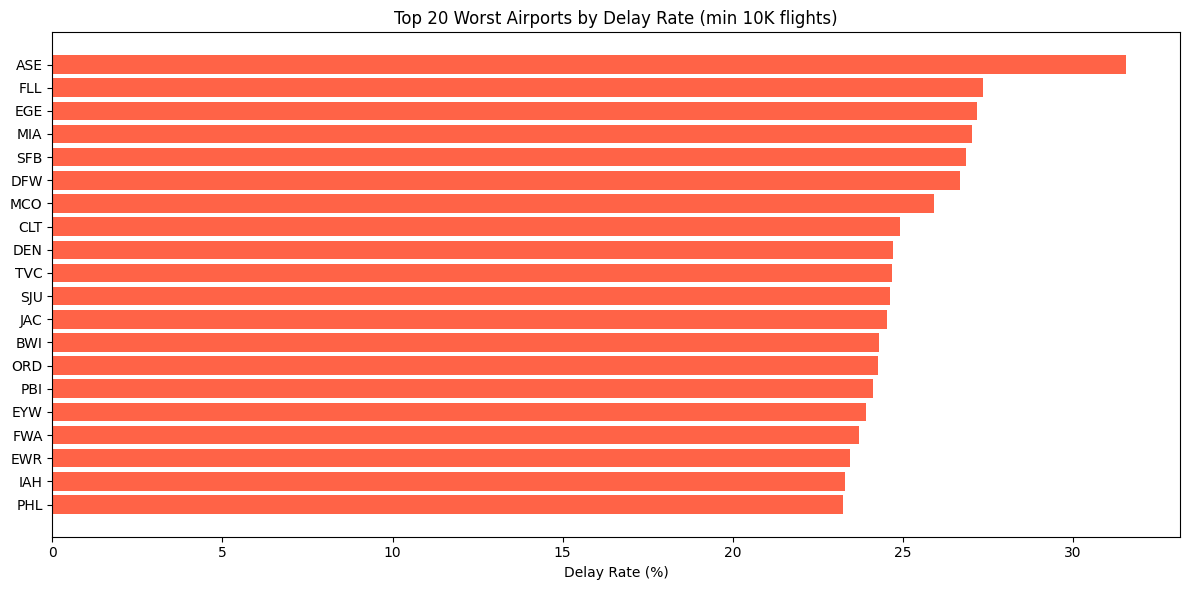

ORIGIN  flights  delay_rate
   ASE    20556    0.315626
   FLL   264272    0.273389
   EGE    10440    0.271648
   MIA   319024    0.270274
   SFB    28774    0.268437
   DFW   893078    0.266636
   MCO   476054    0.259008
   CLT   598595    0.249097
   DEN   902804    0.247071
   TVC    12984    0.246688
   SJU   102108    0.246083
   JAC    16840    0.245368
   BWI   286893    0.243063
   ORD   850994    0.242507
   PBI    85651    0.241235
   EYW    21986    0.239061
   FWA    15344    0.237031
   EWR   376766    0.234326
   IAH   339044    0.232819
   PHL   282615    0.232267


In [29]:
airport_stats = data.groupby('ORIGIN').agg(
    flights=('ARR_DEL15', 'count'),
    delay_rate=('ARR_DEL15', 'mean')
).reset_index()

# Only airports with 10,000+ flights (avoid tiny airports skewing results)
busy = airport_stats[airport_stats['flights'] >= 10000].copy()

worst20 = busy.nlargest(20, 'delay_rate')

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(worst20['ORIGIN'], worst20['delay_rate'] * 100, color='tomato')
ax.set_xlabel('Delay Rate (%)')
ax.set_title('Top 20 Worst Airports by Delay Rate (min 10K flights)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(worst20[['ORIGIN', 'flights', 'delay_rate']].to_string(index=False))

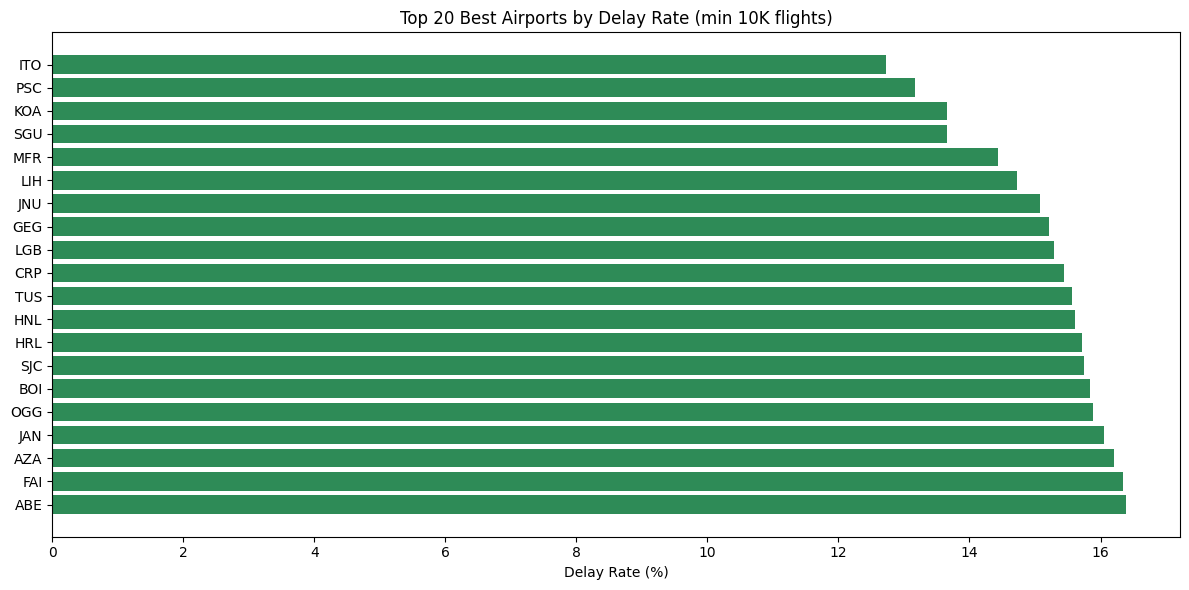

ORIGIN  flights  delay_rate
   ITO    20452    0.127323
   PSC    16938    0.131657
   KOA    48891    0.136508
   SGU    10124    0.136606
   MFR    13545    0.144408
   LIH    47253    0.147271
   JNU    13809    0.150699
   GEG    51880    0.152101
   LGB    50489    0.152865
   CRP    11335    0.154477
   TUS    55488    0.155709
   HNL   180312    0.156068
   HRL    12160    0.157155
   SJC   147027    0.157542
   BOI    67022    0.158396
   OGG    81131    0.158817
   JAN    19907    0.160597
   AZA    17718    0.162039
   FAI    10166    0.163388
   ABE    11596    0.163936


In [30]:
best20 = busy.nsmallest(20, 'delay_rate')

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(best20['ORIGIN'], best20['delay_rate'] * 100, color='seagreen')
ax.set_xlabel('Delay Rate (%)')
ax.set_title('Top 20 Best Airports by Delay Rate (min 10K flights)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(best20[['ORIGIN', 'flights', 'delay_rate']].to_string(index=False))

## Distance vs Delay Rate

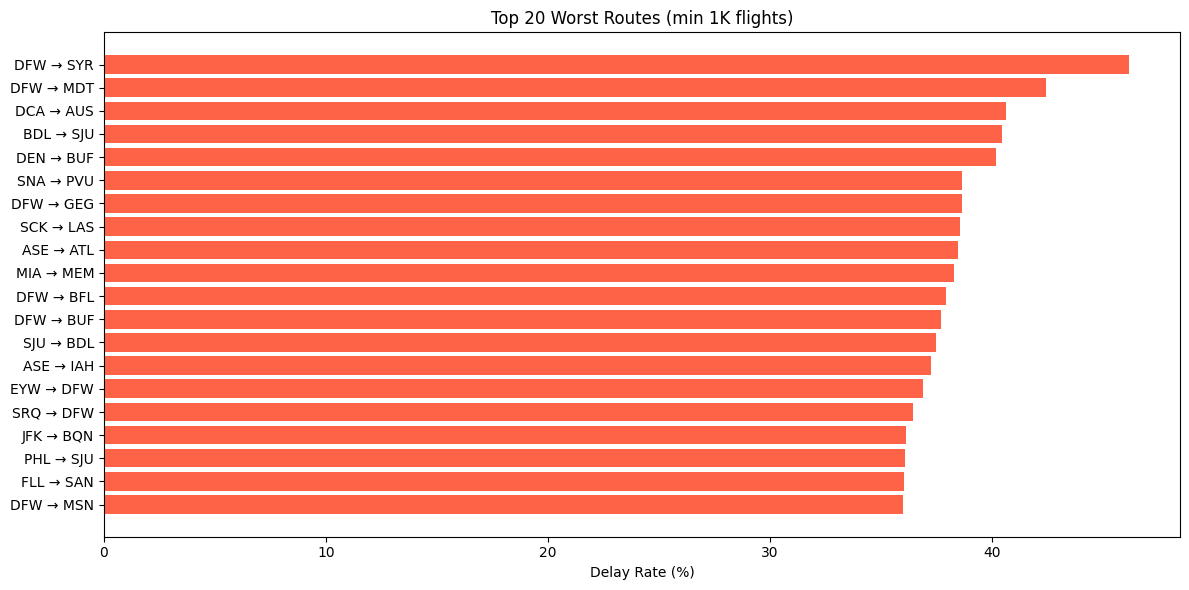

    ROUTE  flights  delay_rate  avg_delay
DFW → SYR     1020    0.461765  37.679412
DFW → MDT     1079    0.424467  38.122335
DCA → AUS     1087    0.406624  20.635695
BDL → SJU     2932    0.404502  29.726126
DEN → BUF     1311    0.401983  20.768879
SNA → PVU     1058    0.386578  53.637051
DFW → GEG     1801    0.386452  29.751805
SCK → LAS     1234    0.385737  29.261750
ASE → ATL     1034    0.384913  36.323985
MIA → MEM     1261    0.383029  28.964314
DFW → BFL     1424    0.379213  29.841994
DFW → BUF     1519    0.377222  24.699144
SJU → BDL     2934    0.374915  25.622018
ASE → IAH     1613    0.372598  28.492870
EYW → DFW     1157    0.369058  32.771824
SRQ → DFW     1136    0.364437  29.697183
JFK → BQN     1807    0.361372  17.079690
PHL → SJU     4348    0.360856  19.894664
FLL → SAN     1099    0.360328  14.732484
DFW → MSN     3148    0.360229  26.577192


In [31]:
route_stats = data.groupby(['ORIGIN', 'DEST']).agg(
    flights=('ARR_DEL15', 'count'),
    delay_rate=('ARR_DEL15', 'mean'),
    avg_delay=('ARR_DELAY', 'mean')
).reset_index()

# Only routes with 1000+ flights
busy_routes = route_stats[route_stats['flights'] >= 1000].copy()
busy_routes['ROUTE'] = busy_routes['ORIGIN'] + ' → ' + busy_routes['DEST']

worst_routes = busy_routes.nlargest(20, 'delay_rate')

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(worst_routes['ROUTE'], worst_routes['delay_rate'] * 100, color='tomato')
ax.set_xlabel('Delay Rate (%)')
ax.set_title('Top 20 Worst Routes (min 1K flights)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(worst_routes[['ROUTE', 'flights', 'delay_rate', 'avg_delay']].to_string(index=False))

## Taxi Out Time Analysis

In [32]:
# Bin distance into groups
data['DIST_GROUP'] = pd.cut(data['DISTANCE'], 
                            bins=[0, 500, 1000, 1500, 2000, 3000, 6000],
                            labels=['0-500', '500-1K', '1K-1.5K', '1.5K-2K', '2K-3K', '3K+'])

dist_stats = data.groupby('DIST_GROUP').agg(
    flights=('ARR_DEL15', 'count'),
    delay_rate=('ARR_DEL15', 'mean')
).reset_index()

print(dist_stats.to_string(index=False))

DIST_GROUP  flights  delay_rate
     0-500  7068831    0.197157
    500-1K  7467513    0.217064
   1K-1.5K  3356467    0.229265
   1.5K-2K  1402008    0.223507
     2K-3K  1249731    0.212027
       3K+    43604    0.203192


/var/folders/_r/scvy88yj1wl9m4x325v7q1200000gn/T/ipykernel_2997/169020161.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dist_stats = data.groupby('DIST_GROUP').agg(


In [33]:
data.columns

Index(['YEAR', 'QUARTER', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE',
       'OP_UNIQUE_CARRIER', 'OP_CARRIER_AIRLINE_ID', 'TAIL_NUM',
       'OP_CARRIER_FL_NUM', 'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_ABR',
       'ORIGIN_STATE_NM', 'DEST', 'DEST_CITY_NAME', 'DEST_STATE_ABR',
       'DEST_STATE_NM', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY',
       'DEP_DELAY_NEW', 'DEP_DEL15', 'DEP_TIME_BLK', 'TAXI_OUT', 'TAXI_IN',
       'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'ARR_DELAY_NEW', 'ARR_DEL15',
       'ARR_TIME_BLK', 'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED',
       'CRS_ELAPSED_TIME', 'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'FLIGHTS',
       'DISTANCE', 'DISTANCE_GROUP', 'CARRIER_DELAY', 'WEATHER_DELAY',
       'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'AIRLINE_NAME',
       'DEP_HOUR', 'DAY_NAME', 'DIST_GROUP'],
      dtype='object')

In [34]:
data['TAXI_GROUP'] = pd.cut(data['TAXI_OUT'], 
                            bins=[0, 10, 20, 30, 45, 60, 200],
                            labels=['0-10', '10-20', '20-30', '30-45', '45-60', '60+'])

taxi_stats = data.groupby('TAXI_GROUP').agg(
    flights=('ARR_DEL15', 'count'),
    delay_rate=('ARR_DEL15', 'mean')
).reset_index()

print(taxi_stats.to_string(index=False))

TAXI_GROUP  flights  delay_rate
      0-10  2702493    0.152378
     10-20 12612126    0.176129
     20-30  3628768    0.239850
     30-45  1218849    0.415215
     45-60   267954    0.772189
       60+   157949    0.979949


/var/folders/_r/scvy88yj1wl9m4x325v7q1200000gn/T/ipykernel_2997/3113859274.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  taxi_stats = data.groupby('TAXI_GROUP').agg(


In [35]:
data.TAXI_GROUP.value_counts()

TAXI_GROUP
10-20    12612126
20-30     3628768
0-10      2702493
30-45     1218849
45-60      267954
60+        157949
Name: count, dtype: int64

## Outlier Check

In [36]:
print("=== Outlier Check ===")
print(f"ARR_DELAY > 500 min: {(data['ARR_DELAY'] > 500).sum():,}")
print(f"ARR_DELAY > 1000 min: {(data['ARR_DELAY'] > 1000).sum():,}")
print(f"TAXI_OUT > 120 min: {(data['TAXI_OUT'] > 120).sum():,}")
print(f"AIR_TIME <= 0: {(data['AIR_TIME'] <= 0).sum():,}")

print("\n=== Duplicate Check ===")
dupes = data.duplicated(subset=['FL_DATE', 'OP_UNIQUE_CARRIER', 
                                 'OP_CARRIER_FL_NUM', 'ORIGIN', 'DEST']).sum()
print(f"Duplicate flights: {dupes:,}")

=== Outlier Check ===
ARR_DELAY > 500 min: 40,107
ARR_DELAY > 1000 min: 9,310
TAXI_OUT > 120 min: 9,337
AIR_TIME <= 0: 0

=== Duplicate Check ===
Duplicate flights: 0


## Delay Cause by Airline

In [11]:
airline_names = {
    'AA': 'American', 'DL': 'Delta', 'UA': 'United', 'WN': 'Southwest',
    'B6': 'JetBlue', 'AS': 'Alaska', 'NK': 'Spirit', 'F9': 'Frontier',
    'G4': 'Allegiant', 'HA': 'Hawaiian', 'MQ': 'Envoy Air', 'OO': 'SkyWest',
    'YX': 'Republic', 'OH': 'PSA Airlines', '9E': 'Endeavor',
}
data['AIRLINE'] = data['OP_UNIQUE_CARRIER'].map(airline_names)

In [39]:
cause_cols = ['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 
              'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']

delayed = data[data['ARR_DEL15'] == 1]

airline_causes = delayed.groupby('AIRLINE')[cause_cols].mean()
airline_causes.columns = ['Carrier', 'Weather', 'NAS', 'Security', 'Late Aircraft']

# Drop security (0.2%, useless) for cleaner view
airline_causes = airline_causes.drop(columns='Security')

print(airline_causes.round(1).sort_values('Late Aircraft', ascending=False).to_string())

              Carrier  Weather   NAS  Late Aircraft
AIRLINE                                            
PSA Airlines     24.7      6.6  11.8           41.7
Frontier         22.7      2.0  14.4           41.5
American         28.5      4.4  11.8           40.0
Allegiant        26.7      9.1  16.2           32.3
JetBlue          29.5      2.0  16.7           32.1
Endeavor         24.7      5.8  18.1           29.4
United           21.4      3.6  18.9           28.2
Southwest        14.6      1.4   9.7           27.6
Envoy Air        14.0      6.9  14.3           27.3
Republic         17.0      4.6  23.5           23.9
Delta            33.5      3.5  13.8           21.5
Spirit           19.4      2.3  29.5           20.1
Alaska           14.8      1.9  13.9           19.8
Hawaiian         28.1      1.3   1.7           17.7
SkyWest          40.6     12.0  11.7           16.7


## Monthly Delay Trend (2023–2025)

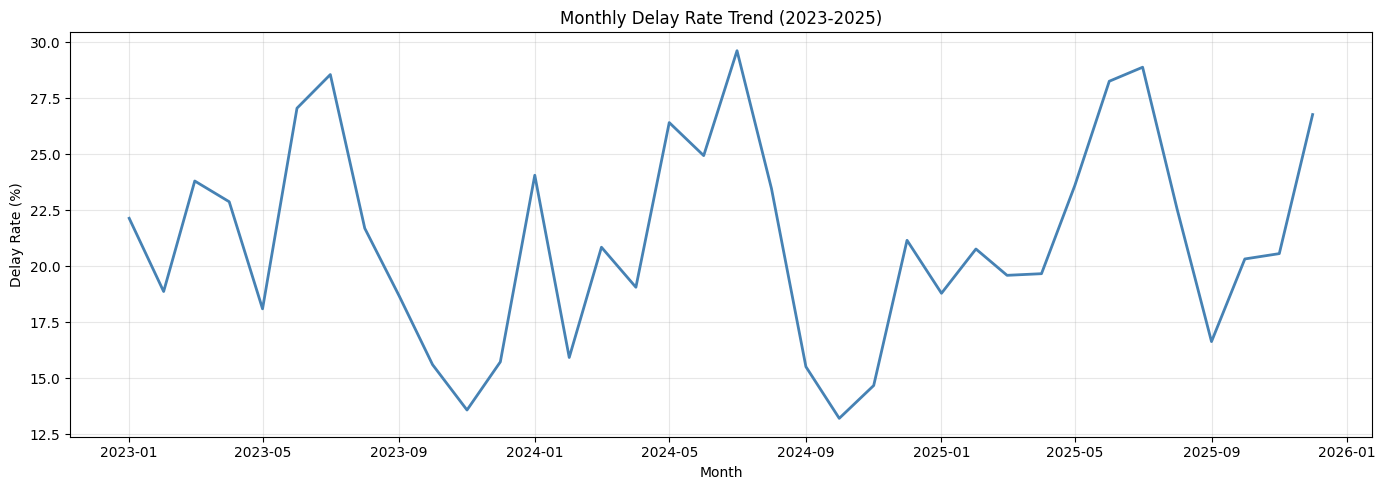

In [40]:
monthly_trend = data.groupby([data['FL_DATE'].dt.to_period('M')]).agg(
    flights=('ARR_DEL15', 'count'),
    delay_rate=('ARR_DEL15', 'mean')
).reset_index()

monthly_trend['FL_DATE'] = monthly_trend['FL_DATE'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_trend['FL_DATE'], monthly_trend['delay_rate'] * 100, 
        color='steelblue', linewidth=2)
ax.set_xlabel('Month')
ax.set_ylabel('Delay Rate (%)')
ax.set_title('Monthly Delay Rate Trend (2023-2025)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Holiday Period Engineering
`IS_HOLIDAY` flags federal holidays ± 2 days before and after.

In [41]:
from pandas.tseries.holiday import USFederalHolidayCalendar

cal = USFederalHolidayCalendar()
holidays = cal.holidays(start='2023-01-01', end='2025-12-31')

# Flag holiday periods (holiday + 2 days before + 2 days after)
holiday_range = set()
for h in holidays:
    for offset in range(-2, 3):
        holiday_range.add(h + pd.Timedelta(days=offset))

data['IS_HOLIDAY'] = data['FL_DATE'].isin(holiday_range).astype(int)

print(f"Holiday period flights: {data['IS_HOLIDAY'].sum():,}")
print(f"Holiday delay rate: {data[data['IS_HOLIDAY']==1]['ARR_DEL15'].mean()*100:.1f}%")
print(f"Non-holiday delay rate: {data[data['IS_HOLIDAY']==0]['ARR_DEL15'].mean()*100:.1f}%")

Holiday period flights: 2,970,796
Holiday delay rate: 20.5%
Non-holiday delay rate: 21.3%


In [42]:
top_airports = data['ORIGIN'].value_counts().head(50)
print(top_airports.to_string())

ORIGIN
ATL    979661
DEN    902804
DFW    893078
ORD    850994
CLT    598595
LAX    572741
PHX    561852
LAS    556960
SEA    486932
MCO    476054
LGA    448129
BOS    418699
DCA    411692
SFO    409744
EWR    376766
DTW    374952
MSP    357344
JFK    352760
IAH    339044
SLC    335788
MIA    319024
BNA    297503
BWI    286893
PHL    282615
SAN    278406
FLL    264272
AUS    261449
MDW    235201
TPA    231893
DAL    215350
STL    189109
HNL    180312
PDX    177273
RDU    172988
HOU    165438
SMF    164396
IAD    157996
MSY    148375
SJC    147027
MCI    144306
IND    137746
SNA    131590
PIT    127098
CMH    126062
SAT    121335
OAK    120833
CLE    120376
CVG    112509
SJU    102108
RSW    101156


In [ ]:
stations = pd.read_csv('dataset/weather/isd-history.csv')
print(stations.columns.tolist())
print(stations.head(3))

['USAF', 'WBAN', 'STATION NAME', 'CTRY', 'STATE', 'ICAO', 'LAT', 'LON', 'ELEV(M)', 'BEGIN', 'END']
     USAF   WBAN STATION NAME CTRY STATE ICAO  LAT  LON  ELEV(M)     BEGIN  \
0  007018  99999   WXPOD 7018  NaN   NaN  NaN  0.0  0.0   7018.0  20110309   
1  007026  99999   WXPOD 7026   AF   NaN  NaN  0.0  0.0   7026.0  20120713   
2  007070  99999   WXPOD 7070   AF   NaN  NaN  0.0  0.0   7070.0  20140923   

        END  
0  20130730  
1  20170822  
2  20150926  


In [44]:
stations.head()

,USAF,WBAN,STATION NAME,CTRY,STATE,ICAO,LAT,LON,ELEV(M),BEGIN,END
0,007018,99999,WXPOD 7018,NaN,NaN,NaN,0.00,0.000,7018.0,20110309,20130730
1,007026,99999,WXPOD 7026,AF,NaN,NaN,0.00,0.000,7026.0,20120713,20170822
2,007070,99999,WXPOD 7070,AF,NaN,NaN,0.00,0.000,7070.0,20140923,20150926
3,008260,99999,WXPOD8270,NaN,NaN,NaN,0.00,0.000,0.0,20050101,20120731
4,008268,99999,WXPOD8278,AF,NaN,NaN,32.95,65.567,1156.7,20100519,20120323


## Airport Selection for Weather Merge
Selecting 100 airports to maximize NOAA weather coverage. Final selection covers 91.3% of all domestic flights.

In [ ]:
top50 = ['ATL','DEN','DFW','ORD','CLT','LAX','PHX','LAS','SEA','MCO',
         'LGA','BOS','DCA','SFO','EWR','DTW','MSP','JFK','IAH','SLC',
         'MIA','BNA','BWI','PHL','SAN','FLL','AUS','MDW','TPA','DAL',
         'STL','HNL','PDX','RDU','HOU','SMF','IAD','MSY','SJC','MCI',
         'IND','SNA','PIT','CMH','SAT','OAK','CLE','CVG','SJU','RSW']

stations['AIRPORT'] = stations['ICAO'].str.strip()

icao_map = {f'K{a}': a for a in top50}
icao_map['PHNL'] = 'HNL' 
icao_map['TJSJ'] = 'SJU'

stations['AIRPORT'] = stations['AIRPORT'].map(icao_map)
matched = stations[stations['AIRPORT'].notna()].copy()

matched = matched[matched['END'] >= 20250101]

matched = matched.sort_values('END', ascending=False).drop_duplicates('AIRPORT')

print(f"Matched {len(matched)} airports out of 50")
print(matched[['USAF', 'WBAN', 'STATION NAME', 'AIRPORT']].sort_values('AIRPORT').to_string(index=False))

Matched 50 airports out of 50
  USAF  WBAN                          STATION NAME AIRPORT
722190 13874    HARTSFIELD-JACKSON ATLANTA INTL AP     ATL
722540 13904         AUSTIN-BERGSTROM INTL AIRPORT     AUS
723270 13897       NASHVILLE INTERNATIONAL AIRPORT     BNA
725090 14739   GEN E L LOGAN INTERNATIONAL AIRPORT     BOS
724060 93721     BALTIMORE-WASHINGTON INTL AIRPORT     BWI
725240 14820    CLEVELAND-HOPKINS INTERNATIONAL AP     CLE
723140 13881    CHARLOTTE/DOUGLAS INTERNATIONAL AP     CLT
724280 14821   PORT COLUMBUS INTERNATIONAL AIRPORT     CMH
724210 93814  CINCINNATI/NORTHERN KENTUCKY INTL AP     CVG
722580 13960             DALLAS LOVE FIELD AIRPORT     DAL
724050 13743      RONALD REAGAN WASHINGTON NATL AP     DCA
725650  3017          DENVER INTERNATIONAL AIRPORT     DEN
722590  3927      DALLAS/FT WORTH INTERNATIONAL AP     DFW
725370 94847    DETROIT METRO WAYNE COUNTY AIRPORT     DTW
725020 14734       NEWARK LIBERTY INTERNATIONAL AP     EWR
747830 12849            FT

In [47]:
data.head()

,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,...,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,AIRLINE_NAME,DEP_HOUR,DAY_NAME,DIST_GROUP,TAXI_GROUP,AIRLINE,IS_HOLIDAY
0,2023,1,1,1,7,2023-01-01,9E,20363,N131EV,5244.0,...,NaN,NaN,NaN,Endeavor Air,15,Sun,500-1K,10-20,Endeavor,1
1,2023,1,1,1,7,2023-01-01,9E,20363,N131EV,5317.0,...,NaN,NaN,NaN,Endeavor Air,9,Sun,500-1K,20-30,Endeavor,1
2,2023,1,1,1,7,2023-01-01,9E,20363,N131EV,5397.0,...,NaN,NaN,NaN,Endeavor Air,21,Sun,0-500,20-30,Endeavor,1
3,2023,1,1,1,7,2023-01-01,9E,20363,N133EV,5076.0,...,NaN,NaN,NaN,Endeavor Air,11,Sun,500-1K,10-20,Endeavor,1
4,2023,1,1,1,7,2023-01-01,9E,20363,N133EV,5076.0,...,NaN,NaN,NaN,Endeavor Air,14,Sun,500-1K,10-20,Endeavor,1


In [48]:
data.ORIGIN_CITY_NAME.value_counts()

ORIGIN_CITY_NAME
Chicago, IL                      1086195
Atlanta, GA                       979661
Denver, CO                        902804
Dallas/Fort Worth, TX             893078
New York, NY                      800889
                                  ...   
Greenville, NC                       113
Owensboro, KY                         42
Vero Beach, FL                        41
Pueblo, CO                            25
Newport News/Williamsburg, VA          5
Name: count, Length: 356, dtype: int64

In [49]:
top50 = ['ATL','DEN','DFW','ORD','CLT','LAX','PHX','LAS','SEA','MCO',
         'LGA','BOS','DCA','SFO','EWR','DTW','MSP','JFK','IAH','SLC',
         'MIA','BNA','BWI','PHL','SAN','FLL','AUS','MDW','TPA','DAL',
         'STL','HNL','PDX','RDU','HOU','SMF','IAD','MSY','SJC','MCI',
         'IND','SNA','PIT','CMH','SAT','OAK','CLE','CVG','SJU','RSW']

covered = data[data['ORIGIN'].isin(top50)].shape[0]
print(f"Flights from top 50 airports: {covered:,} ({covered/len(data)*100:.1f}%)")

Flights from top 50 airports: 16,225,228 (78.8%)


In [50]:
both_covered = data[
    data['ORIGIN'].isin(top50) & data['DEST'].isin(top50)
].shape[0]

either_covered = data[
    data['ORIGIN'].isin(top50) | data['DEST'].isin(top50)
].shape[0]

print(f"Both origin AND dest in top 50: {both_covered:,} ({both_covered/len(data)*100:.1f}%)")
print(f"At least one in top 50: {either_covered:,} ({either_covered/len(data)*100:.1f}%)")

Both origin AND dest in top 50: 12,199,409 (59.3%)
At least one in top 50: 20,247,525 (98.3%)


In [ ]:
all_airports = pd.concat([data['ORIGIN'], data['DEST']]).value_counts()
missing = all_airports[~all_airports.index.isin(top50)].head(30)
print(missing.to_string())

BUR    179203
PBI    171423
JAX    171020
MKE    162275
OGG    162251
ONT    151649
CHS    146983
ABQ    144189
OMA    140095
SDF    138732
MEM    136989
OKC    134658
BOI    134117
BDL    132067
BUF    124423
ORF    121604
RNO    121542
TUS    111063
SAV    109662
ANC    108806
RIC    107884
GRR    105075
GEG    103819
TUL    102102
ELP    101911
LGB    101019
BHM     98411
KOA     97812
SRQ     96001
LIH     94494


In [52]:
next30 = ['BUR','PBI','JAX','MKE','OGG','ONT','CHS','ABQ','OMA','SDF',
          'MEM','OKC','BOI','BDL','BUF','ORF','RNO','TUS','SAV','ANC',
          'RIC','GRR','GEG','TUL','ELP','LGB','BHM','KOA','SRQ','LIH']

top80 = top50 + next30

both_covered = data[
    data['ORIGIN'].isin(top80) & data['DEST'].isin(top80)
].shape[0]

print(f"Both covered with 80 airports: {both_covered:,} ({both_covered/len(data)*100:.1f}%)")

Both covered with 80 airports: 15,865,220 (77.1%)


In [53]:
next30 = ['BUR','PBI','JAX','MKE','OGG','ONT','CHS','ABQ','OMA','SDF',
          'MEM','OKC','BOI','BDL','BUF','ORF','RNO','TUS','SAV','ANC',
          'RIC','GRR','GEG','TUL','ELP','LGB','BHM','KOA','SRQ','LIH']

stations = pd.read_csv('dataset/weather/isd-history.csv')

# Build ICAO mapping
icao_map = {f'K{a}': a for a in next30}
# Hawaii airports
icao_map['PHOG'] = 'OGG'
icao_map['PHKO'] = 'KOA'
icao_map['PHLI'] = 'LIH'
# Alaska
icao_map['PANC'] = 'ANC'

stations['AIRPORT'] = stations['ICAO'].str.strip().map(icao_map)
matched = stations[stations['AIRPORT'].notna()].copy()
matched = matched[matched['END'] >= 20250101]
matched = matched.sort_values('END', ascending=False).drop_duplicates('AIRPORT')

print(f"Matched {len(matched)} out of 30")
print(matched[['USAF', 'WBAN', 'STATION NAME', 'AIRPORT']].sort_values('AIRPORT').to_string(index=False))

Matched 30 out of 30
  USAF  WBAN                           STATION NAME AIRPORT
723650 23050       ALBUQUERQUE INTL SUNPORT AIRPORT     ABQ
702730 26451             TED STEVENS ANCHORAGE INTL     ANC
725080 14740          BRADLEY INTERNATIONAL AIRPORT     BDL
722280 13876       BIRMINGHAM INTERNATIONAL AIRPORT     BHM
726810 24131    BOISE AIR TERMINAL/GOWEN FD AIRPORT     BOI
725280 14733   BUFFALO NIAGARA INTERNATIONAL AIRPOR     BUF
722880 23152             BURBANK-GLENDALE-PASA ARPT     BUR
722080 13880   CHARLESTON AFB/INTERNATIONAL AIRPORT     CHS
722700 23044          EL PASO INTERNATIONAL AIRPORT     ELP
727850 24157          SPOKANE INTERNATIONAL AIRPORT     GEG
726350 94860    GERALD R FORD INTERNATIONAL AIRPORT     GRR
722060 13889     JACKSONVILLE INTERNATIONAL AIRPORT     JAX
911975 21510              KONA INTL AT KEAHOLE ARPT     KOA
722970 23129 LONG BEACH / DAUGHERTY FIELD / AIRPORT     LGB
911650 22536                          LIHUE AIRPORT     LIH
723340 13893       

In [54]:
top80 = top50 + next30

all_airports = pd.concat([data['ORIGIN'], data['DEST']]).value_counts()
next20 = all_airports[~all_airports.index.isin(top80)].head(20)
print(next20.to_string())

# Check coverage with 100 airports
top100 = top80 + next20.index.tolist()
both_covered = data[
    data['ORIGIN'].isin(top100) & data['DEST'].isin(top100)
].shape[0]
print(f"\nBoth covered with 100 airports: {both_covered:,} ({both_covered/len(data)*100:.1f}%)")

MYR    88161
PVD    87990
DSM    87769
GSP    86354
TYS    85508
PSP    84394
PNS    75946
XNA    75426
COS    74037
LIT    73017
SYR    72596
FAT    72006
ALB    71734
HPN    70321
MSN    68947
ROC    68746
AVL    65582
GSO    65107
PWM    65101
BZN    60923

Both covered with 100 airports: 17,320,139 (84.1%)


In [55]:
next20_list = ['MYR','PVD','DSM','GSP','TYS','PSP','PNS','XNA','COS','LIT',
               'SYR','FAT','ALB','HPN','MSN','ROC','AVL','GSO','PWM','BZN']

stations = pd.read_csv('dataset/weather/isd-history.csv')

icao_map = {f'K{a}': a for a in next20_list}
stations['AIRPORT'] = stations['ICAO'].str.strip().map(icao_map)
matched = stations[stations['AIRPORT'].notna()].copy()
matched = matched[matched['END'] >= 20250101]
matched = matched.sort_values('END', ascending=False).drop_duplicates('AIRPORT')

print(f"Matched {len(matched)} out of 20")
print(matched[['USAF', 'WBAN', 'STATION NAME', 'AIRPORT']].sort_values('AIRPORT').to_string(index=False))

Matched 20 out of 20
  USAF  WBAN                          STATION NAME AIRPORT
725180 14735          ALBANY INTERNATIONAL AIRPORT     ALB
723150  3812            ASHEVILLE REGIONAL AIRPORT     AVL
726797 24132                GALLATIN FIELD AIRPORT     BZN
724660 93037 CITY OF COLORADO SPRINGS MUNICIPAL AP     COS
725460 14933      DES MOINES INTERNATIONAL AIRPORT     DSM
723890 93193 FRESNO YOSEMITE INTERNATIONAL AIRPORT     FAT
723170 13723  PIEDMONT TRIAD INTERNATIONAL AIRPORT     GSO
723120  3870   GREENVILLE-SPARTANBURG INTL AIRPORT     GSP
725037 94745            WESTCHESTER COUNTY AIRPORT     HPN
723403 13963                   ADAMS FIELD AIRPORT     LIT
726410 14837  DANE CO REGIONAL-TRUAX FIELD AIRPORT     MSN
747910 13717             MYRTLE BEACH INTL AIRPORT     MYR
722223 13899            PENSACOLA REGIONAL AIRPORT     PNS
722868 93138             PALM SPRINGS INTL AIRPORT     PSP
725070 14765        THEODORE F GREEN STATE AIRPORT     PVD
726060 14764     PORTLAND INTERNATI

In [56]:
data.AIRLINE.value_counts()

AIRLINE
Southwest       4202672
Delta           2983204
American        2847015
United          2252227
SkyWest         2223949
Republic         915838
Envoy Air        791847
JetBlue          730301
Alaska           724893
Spirit           705662
PSA Airlines     651427
Frontier         571133
Endeavor         391977
Allegiant        359199
Hawaiian         236810
Name: count, dtype: int64

In [57]:
data.columns

Index(['YEAR', 'QUARTER', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE',
       'OP_UNIQUE_CARRIER', 'OP_CARRIER_AIRLINE_ID', 'TAIL_NUM',
       'OP_CARRIER_FL_NUM', 'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_ABR',
       'ORIGIN_STATE_NM', 'DEST', 'DEST_CITY_NAME', 'DEST_STATE_ABR',
       'DEST_STATE_NM', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY',
       'DEP_DELAY_NEW', 'DEP_DEL15', 'DEP_TIME_BLK', 'TAXI_OUT', 'TAXI_IN',
       'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'ARR_DELAY_NEW', 'ARR_DEL15',
       'ARR_TIME_BLK', 'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED',
       'CRS_ELAPSED_TIME', 'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'FLIGHTS',
       'DISTANCE', 'DISTANCE_GROUP', 'CARRIER_DELAY', 'WEATHER_DELAY',
       'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'AIRLINE_NAME',
       'DEP_HOUR', 'DAY_NAME', 'DIST_GROUP', 'TAXI_GROUP', 'AIRLINE',
       'IS_HOLIDAY'],
      dtype='object')

## Validate Financial Data Coverage
Confirm all 15 carriers in flight data have matching BTS Form 41 financial records.

In [ ]:
fin_domestic = pd.read_parquet('dataset/financials/financials_clean.parquet')

In [ ]:
flight_carriers = set(data['OP_UNIQUE_CARRIER'].unique())
fin_carriers = set(fin_domestic['UNIQUE_CARRIER'].unique())

print(f"In flights but NOT in financials: {sorted(flight_carriers - fin_carriers)}")
print(f"In financials but NOT in flights: {sorted(fin_carriers - flight_carriers)}")

In flights but NOT in financials: []
In financials but NOT in flights: []


## Final Data Integrity Check

In [60]:
# check duplicates and overlaps from Step 1 engineering
print("── DISTANCE_GROUP vs DIST_GROUP ─────────────────────────────────────")
print(data[["DISTANCE_GROUP", "DIST_GROUP"]].head(5))
print("Identical?", (data["DISTANCE_GROUP"] == data["DIST_GROUP"]).all())

print("\n── OP_UNIQUE_CARRIER vs AIRLINE ─────────────────────────────────────")
print(data[["OP_UNIQUE_CARRIER", "AIRLINE"]].head(5))
print("Identical?", (data["OP_UNIQUE_CARRIER"] == data["AIRLINE"]).all())

print("\n── DEP_HOUR check (was already in data.parquet) ─────────────────────")
print(data["DEP_HOUR"].value_counts().sort_index().head(5))

print("\n── IS_HOLIDAY sample ────────────────────────────────────────────────")
print(data["IS_HOLIDAY"].value_counts())

print("\n── TAXI_GROUP sample ────────────────────────────────────────────────")
print(data["TAXI_GROUP"].value_counts())

── DISTANCE_GROUP vs DIST_GROUP ─────────────────────────────────────
   DISTANCE_GROUP DIST_GROUP
0               3     500-1K
1               3     500-1K
2               2      0-500
3               3     500-1K
4               3     500-1K
Identical? False

── OP_UNIQUE_CARRIER vs AIRLINE ─────────────────────────────────────
  OP_UNIQUE_CARRIER   AIRLINE
0                9E  Endeavor
1                9E  Endeavor
2                9E  Endeavor
3                9E  Endeavor
4                9E  Endeavor
Identical? False

── DEP_HOUR check (was already in data.parquet) ─────────────────────
DEP_HOUR
0    33941
1    11163
2     4498
3     2482
4     1240
Name: count, dtype: int64

── IS_HOLIDAY sample ────────────────────────────────────────────────
IS_HOLIDAY
0    17617358
1     2970796
Name: count, dtype: int64

── TAXI_GROUP sample ────────────────────────────────────────────────
TAXI_GROUP
10-20    12612126
20-30     3628768
0-10      2702493
30-45     1218849
45-60      267954
60

In [ ]:
print("── CANCELLED / DIVERTED (should be all 0) ───────────────────────────")
print(data["CANCELLED"].value_counts())
print(data["DIVERTED"].value_counts())

print("\n── FLIGHTS col (should be all 1) ────────────────────────────────────")
print(data["FLIGHTS"].value_counts())

print("\n── DISTANCE_GROUP vs DIST_GROUP ─────────────────────────────────────")
print(data[["DISTANCE_GROUP", "DIST_GROUP"]].head(8))

print("\n── AIRLINE vs AIRLINE_NAME ──────────────────────────────────────────")
print(data[["AIRLINE", "AIRLINE_NAME"]].head(8))

print("\n── DEP_HOUR duplicate check ─────────────────────────────────────────")

dep_hour_from_crs = (data["CRS_DEP_TIME"] // 100).clip(0, 23)
print("DEP_HOUR matches CRS_DEP_TIME//100?", (data["DEP_HOUR"] == dep_hour_from_crs).all())

── CANCELLED / DIVERTED (should be all 0) ───────────────────────────
CANCELLED
0.0    20588154
Name: count, dtype: int64
DIVERTED
0.0    20588154
Name: count, dtype: int64

── FLIGHTS col (should be all 1) ────────────────────────────────────
FLIGHTS
1.0    20588154
Name: count, dtype: int64

── DISTANCE_GROUP vs DIST_GROUP ─────────────────────────────────────
   DISTANCE_GROUP DIST_GROUP
0               3     500-1K
1               3     500-1K
2               2      0-500
3               3     500-1K
4               3     500-1K
5               3     500-1K
6               3     500-1K
7               3     500-1K

── AIRLINE vs AIRLINE_NAME ──────────────────────────────────────────
    AIRLINE  AIRLINE_NAME
0  Endeavor  Endeavor Air
1  Endeavor  Endeavor Air
2  Endeavor  Endeavor Air
3  Endeavor  Endeavor Air
4  Endeavor  Endeavor Air
5  Endeavor  Endeavor Air
6  Endeavor  Endeavor Air
7  Endeavor  Endeavor Air

── DEP_HOUR duplicate check ────────────────────────────────────────

## Save EDA Dataset

In [62]:
data.to_parquet("dataset/data.parquet", index=False, engine="pyarrow", compression="snappy")
print("✅ Saved:", len(data.columns), "columns")
print(data.columns.tolist())

✅ Saved: 53 columns
['YEAR', 'QUARTER', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE', 'OP_UNIQUE_CARRIER', 'OP_CARRIER_AIRLINE_ID', 'TAIL_NUM', 'OP_CARRIER_FL_NUM', 'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_ABR', 'ORIGIN_STATE_NM', 'DEST', 'DEST_CITY_NAME', 'DEST_STATE_ABR', 'DEST_STATE_NM', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'DEP_DELAY_NEW', 'DEP_DEL15', 'DEP_TIME_BLK', 'TAXI_OUT', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'ARR_DELAY_NEW', 'ARR_DEL15', 'ARR_TIME_BLK', 'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'FLIGHTS', 'DISTANCE', 'DISTANCE_GROUP', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'AIRLINE_NAME', 'DEP_HOUR', 'DAY_NAME', 'DIST_GROUP', 'TAXI_GROUP', 'AIRLINE', 'IS_HOLIDAY']
